In [ ]:
!pip install graphviz

from collections import deque
from graphviz import Digraph
from IPython.display import Image, display

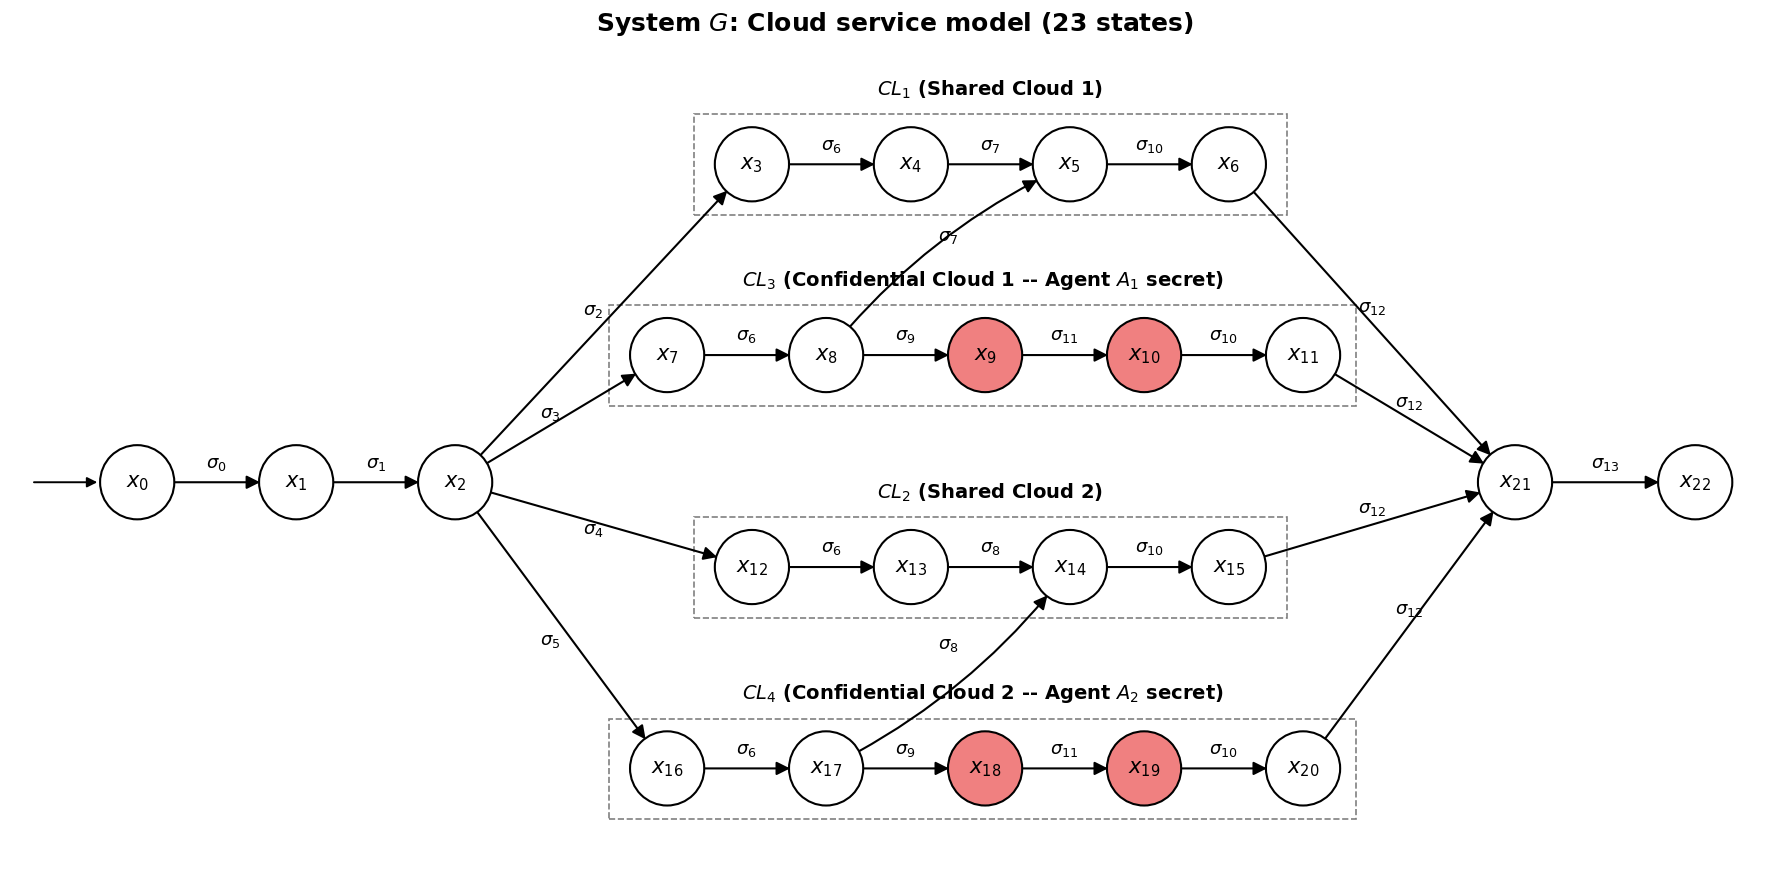

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

# ============================================================
# LARGE CLOUD-SERVICE SYSTEM — MANUAL PUBLICATION LAYOUT
# ============================================================

# Secret states
S1 = {'x_9', 'x_10'}
S2 = {'x_18', 'x_19'}

# ============================================================
# FIXED STATE POSITIONS
# ============================================================

pos = {
    'x_0':  (0.0, 0.0),
    'x_1':  (1.5, 0.0),
    'x_2':  (3.0, 0.0),

    # CL1
    'x_3':  (5.8, 3.0),
    'x_4':  (7.3, 3.0),
    'x_5':  (8.8, 3.0),
    'x_6':  (10.3, 3.0),

    # CL3
    'x_7':  (5.0, 1.2),
    'x_8':  (6.5, 1.2),
    'x_9':  (8.0, 1.2),
    'x_10': (9.5, 1.2),
    'x_11': (11.0, 1.2),

    # CL2
    'x_12': (5.8, -0.8),
    'x_13': (7.3, -0.8),
    'x_14': (8.8, -0.8),
    'x_15': (10.3, -0.8),

    # CL4
    'x_16': (5.0, -2.7),
    'x_17': (6.5, -2.7),
    'x_18': (8.0, -2.7),
    'x_19': (9.5, -2.7),
    'x_20': (11.0, -2.7),

    # Common ending
    'x_21': (13.0, 0.0),
    'x_22': (14.7, 0.0)
}

# ============================================================
# NORMAL SYSTEM TRANSITIONS
# ============================================================

transitions = [
    ('x_0',  'x_1',  r'$\sigma_0$'),
    ('x_1',  'x_2',  r'$\sigma_1$'),

    # CL1
    ('x_2',  'x_3',  r'$\sigma_2$'),
    ('x_3',  'x_4',  r'$\sigma_6$'),
    ('x_4',  'x_5',  r'$\sigma_7$'),
    ('x_5',  'x_6',  r'$\sigma_{10}$'),
    ('x_6',  'x_21', r'$\sigma_{12}$'),

    # CL3
    ('x_2',  'x_7',  r'$\sigma_3$'),
    ('x_7',  'x_8',  r'$\sigma_6$'),
    ('x_8',  'x_9',  r'$\sigma_9$'),
    ('x_9',  'x_10', r'$\sigma_{11}$'),
    ('x_10', 'x_11', r'$\sigma_{10}$'),
    ('x_11', 'x_21', r'$\sigma_{12}$'),

    # CL2
    ('x_2',  'x_12', r'$\sigma_4$'),
    ('x_12', 'x_13', r'$\sigma_6$'),
    ('x_13', 'x_14', r'$\sigma_8$'),
    ('x_14', 'x_15', r'$\sigma_{10}$'),
    ('x_15', 'x_21', r'$\sigma_{12}$'),

    # CL4
    ('x_2',  'x_16', r'$\sigma_5$'),
    ('x_16', 'x_17', r'$\sigma_6$'),
    ('x_17', 'x_18', r'$\sigma_9$'),
    ('x_18', 'x_19', r'$\sigma_{11}$'),
    ('x_19', 'x_20', r'$\sigma_{10}$'),
    ('x_20', 'x_21', r'$\sigma_{12}$'),

    # Common completion
    ('x_21', 'x_22', r'$\sigma_{13}$')
]

# ============================================================
# CROSS LINKS
# Every entry must have:
# source, destination, label, curvature
# ============================================================

cross_links = [
   # ('x_5',  'x_11', r'$\sigma_{10}$',  0.12),
    #('x_14', 'x_20', r'$\sigma_{10}$', -0.12),
    ('x_8',  'x_5',  r'$\sigma_7$',    -0.12),
    ('x_17', 'x_14', r'$\sigma_8$',     0.12)
]

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(18, 9))

node_radius = 0.35

# ============================================================
# DRAW NODE
# ============================================================

def draw_node(state):
    x, y = pos[state]

    if state in S1 or state in S2:
        facecolor = 'lightcoral'
    else:
        facecolor = 'white'

    circle = Circle(
        (x, y),
        node_radius,
        facecolor=facecolor,
        edgecolor='black',
        linewidth=1.5,
        zorder=3
    )

    ax.add_patch(circle)

    number = state.split('_')[1]

    ax.text(
        x,
        y,
        rf'$x_{{{number}}}$',
        ha='center',
        va='center',
        fontsize=15,
        zorder=4
    )

# ============================================================
# DRAW ARROW
# ============================================================

def draw_arrow(
    src,
    dst,
    label,
    rad=0.0,
    label_dx=0.0,
    label_dy=0.18
):
    x1, y1 = pos[src]
    x2, y2 = pos[dst]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle='-|>',
        mutation_scale=20,
        linewidth=1.5,
        color='black',
        shrinkA=26,
        shrinkB=26,
        connectionstyle=f'arc3,rad={rad}',
        zorder=2
    )

    ax.add_patch(arrow)

    mx = (x1 + x2) / 2 + label_dx
    my = (y1 + y2) / 2 + label_dy

    ax.text(
        mx,
        my,
        label,
        fontsize=13,
        ha='center',
        va='center',
        zorder=5
    )

# ============================================================
# CLOUD BOXES
# ============================================================

boxes = [
    (5.25, 2.52, 5.60, 0.95, r'$CL_1$ (Shared Cloud 1)'),

    (
        4.45, 0.72, 7.05, 0.95,
        r'$CL_3$ (Confidential Cloud 1 -- Agent $A_1$ secret)'
    ),

   (5.25, -1.28, 5.60, 0.95, r'$CL_2$ (Shared Cloud 2)'),
    (
        4.45, -3.18, 7.05, 0.95,
        r'$CL_4$ (Confidential Cloud 2 -- Agent $A_2$ secret)'
    )
]

for x, y, width, height, label in boxes:

    rect = Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linestyle='--',
        linewidth=1.2,
        edgecolor='gray',
        zorder=1
    )

    ax.add_patch(rect)

    ax.text(
        x + width / 2,
        y + height + 0.13,
        label,
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold'
    )

# ============================================================
# DRAW STATES
# ============================================================

for state in pos:
    draw_node(state)

# ============================================================
# DRAW NORMAL TRANSITIONS
# ============================================================

for src, dst, label in transitions:

    if src == 'x_2':

        if dst == 'x_3':
            draw_arrow(
                src, dst, label,
                label_dx=-0.10,
                label_dy=0.12
            )

        elif dst == 'x_7':
            draw_arrow(
                src, dst, label,
                label_dx=-0.10,
                label_dy=0.05
            )

        elif dst == 'x_12':
            draw_arrow(
                src, dst, label,
                label_dx=-0.10,
                label_dy=-0.05
            )

        elif dst == 'x_16':
            draw_arrow(
                src, dst, label,
                label_dx=-0.10,
                label_dy=-0.14
            )

    elif dst == 'x_21':

        draw_arrow(
            src,
            dst,
            label,
            label_dy=0.15
        )

    else:

        draw_arrow(
            src,
            dst,
            label
        )

# ============================================================
# DRAW CROSS LINKS
# ============================================================

for src, dst, label, curvature in cross_links:

    draw_arrow(
        src,
        dst,
        label,
        rad=curvature,
        label_dy=0.22
    )

# ============================================================
# INITIAL-STATE ARROW
# ============================================================

initial_arrow = FancyArrowPatch(
    (-1.0, 0),
    (-0.35, 0),
    arrowstyle='-|>',
    mutation_scale=15,
    linewidth=1.4,
    color='black'
)

ax.add_patch(initial_arrow)

# ============================================================
# FIGURE SETTINGS
# ============================================================

ax.set_xlim(-1.2, 15.5)
ax.set_ylim(-3.8, 4.0)

ax.set_aspect('equal')
ax.axis('off')

ax.set_title(
    r'System $G$: Cloud service model (23 states)',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    'Cloud__service_system_manual.png',
    dpi=400,
    bbox_inches='tight'
)

plt.savefig(
    'Cloud__service_system_manual.pdf',
    bbox_inches='tight'
)

plt.show()

Agent A1 observable events:
['sigma_0', 'sigma_1', 'sigma_10', 'sigma_12', 'sigma_13', 'sigma_3', 'sigma_4', 'sigma_5', 'sigma_6', 'sigma_8', 'sigma_9']

Agent A1 unobservable events:
['sigma_11', 'sigma_2', 'sigma_7']

Agent A2 observable events:
['sigma_0', 'sigma_1', 'sigma_10', 'sigma_12', 'sigma_13', 'sigma_2', 'sigma_3', 'sigma_6', 'sigma_7', 'sigma_9']

Agent A2 unobservable events:
['sigma_11', 'sigma_4', 'sigma_5', 'sigma_8']

Defender observable events:
['sigma_0', 'sigma_1', 'sigma_10', 'sigma_11', 'sigma_12', 'sigma_13', 'sigma_2', 'sigma_3', 'sigma_4', 'sigma_5', 'sigma_6', 'sigma_7', 'sigma_8', 'sigma_9']

Defender unobservable events:
[]

Observer O1 for Agent A1
Number of observer states = 19
Number of observer transitions = 23

Observer states:
{'x_0'}
{'x_1'}
{'x_6'}
{'x_7'}
{'x_11'}
{'x_12'}
{'x_13'}
{'x_14'}
{'x_15'}
{'x_16'}
{'x_17'}
{'x_20'}
{'x_21'}
{'x_22'}
{'x_2', 'x_3'}
{'x_4', 'x_5'}
{'x_8', 'x_5'}
{'x_9', 'x_10'}
{'x_19', 'x_18'}

Observer transitions:
{'x_0

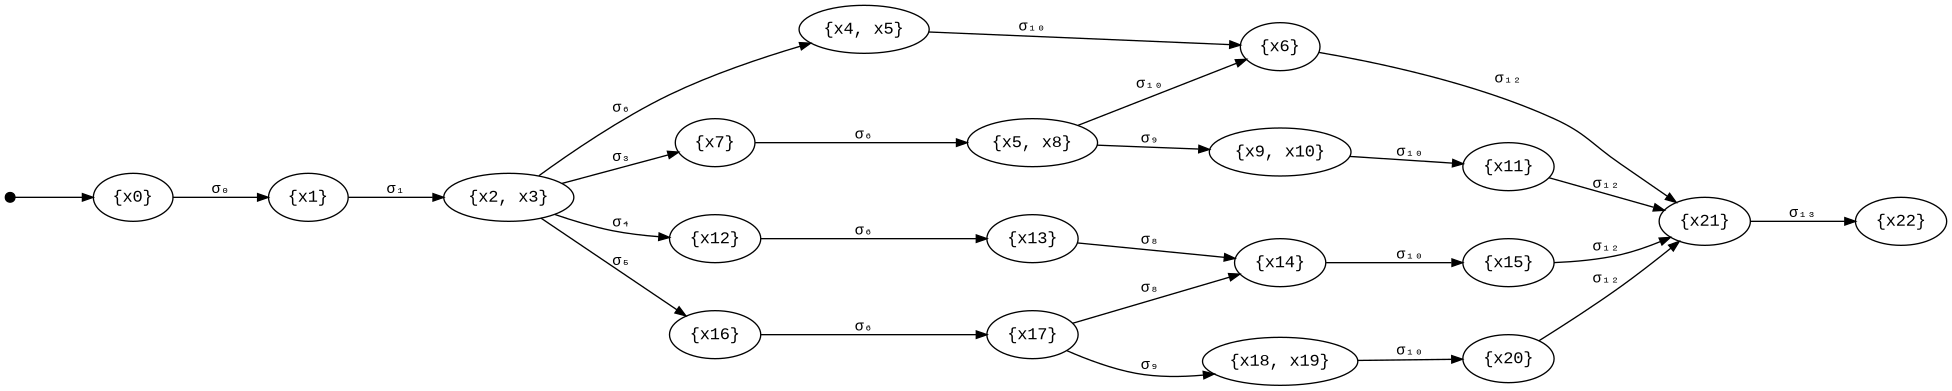



Observer O2:


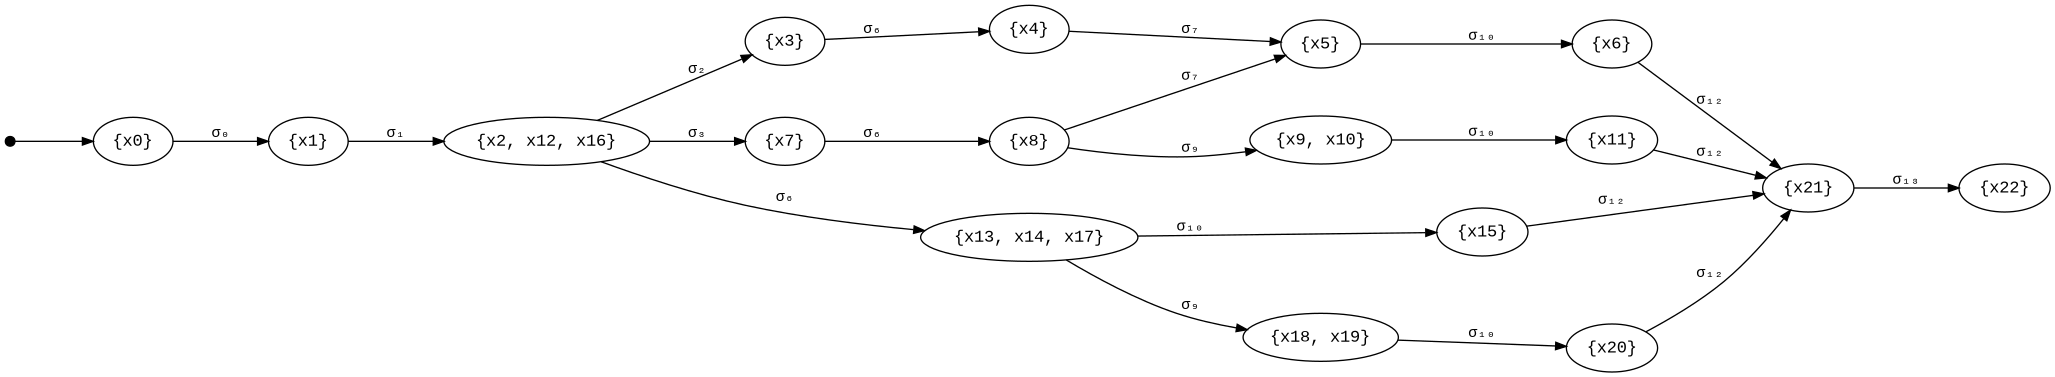



Defender Observer OD:


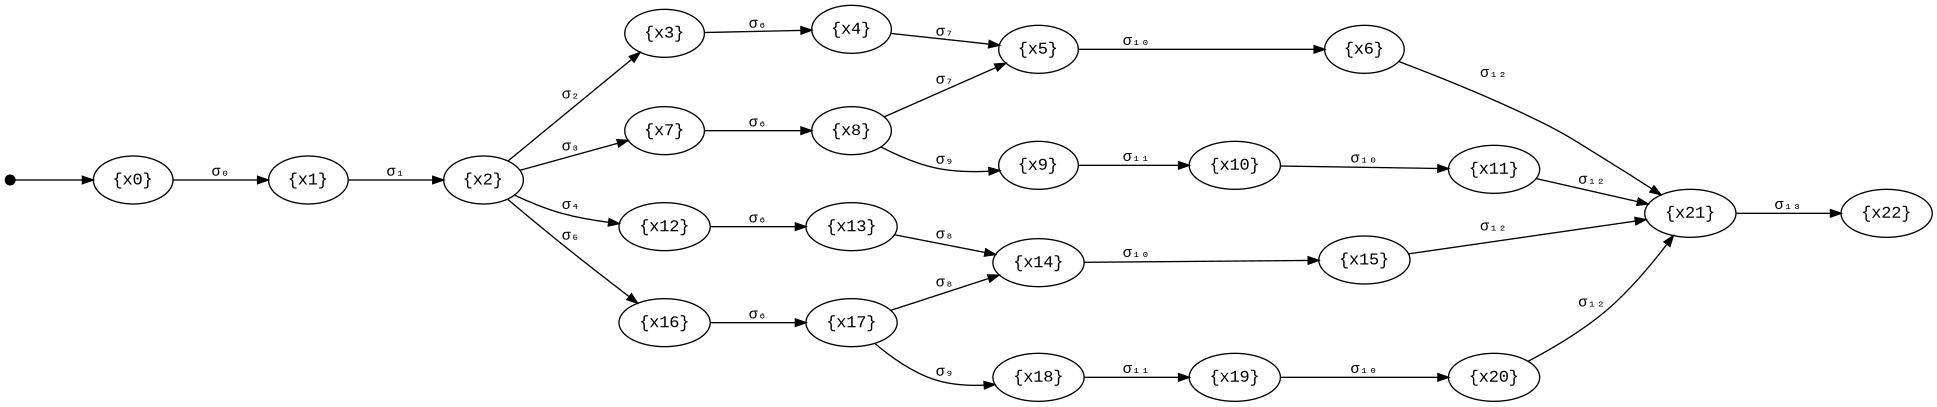

In [9]:
# ============================================================
# LARGE CLOUD EXAMPLE: O1, O2 AND OD OBSERVER CONSTRUCTION
# ============================================================

!pip install graphviz

from collections import deque
from graphviz import Digraph
from IPython.display import Image, display


# ============================================================
# 1. SYSTEM MODEL
# ============================================================

dfa = {

    'states': {
        'x_0', 'x_1', 'x_2',
        'x_3', 'x_4', 'x_5', 'x_6',
        'x_7', 'x_8', 'x_9', 'x_10', 'x_11',
        'x_12', 'x_13', 'x_14', 'x_15',
        'x_16', 'x_17', 'x_18', 'x_19', 'x_20',
        'x_21', 'x_22'
    },

    'alphabet': {
        'sigma_0', 'sigma_1', 'sigma_2', 'sigma_3',
        'sigma_4', 'sigma_5', 'sigma_6', 'sigma_7',
        'sigma_8', 'sigma_9', 'sigma_10', 'sigma_11',
        'sigma_12', 'sigma_13'
    },

    # IMPORTANT:
    # Each transition maps to a SET of successor states.
    # This preserves your two sigma_10 branches.
    'transition': {

        # Initial path
        ('x_0', 'sigma_0'): {'x_1'},
        ('x_1', 'sigma_1'): {'x_2'},

        # ----------------------------------------------------
        # CL1 : Shared Cloud 1
        # ----------------------------------------------------
        ('x_2', 'sigma_2'): {'x_3'},
        ('x_3', 'sigma_6'): {'x_4'},
        ('x_4', 'sigma_7'): {'x_5'},


        ('x_5', 'sigma_10'): {'x_6'},

        ('x_6', 'sigma_12'): {'x_21'},

        # ----------------------------------------------------
        # CL3 : Confidential Cloud 1
        # S1 = {x9, x10}
        # ----------------------------------------------------
        ('x_2', 'sigma_3'): {'x_7'},
        ('x_7', 'sigma_6'): {'x_8'},

        # cross connection to CL1
        ('x_8', 'sigma_7'): {'x_5'},

        ('x_8', 'sigma_9'): {'x_9'},
        ('x_9', 'sigma_11'): {'x_10'},
        ('x_10', 'sigma_10'): {'x_11'},
        ('x_11', 'sigma_12'): {'x_21'},

        # ----------------------------------------------------
        # CL2 : Shared Cloud 2
        # ----------------------------------------------------
        ('x_2', 'sigma_4'): {'x_12'},
        ('x_12', 'sigma_6'): {'x_13'},
        ('x_13', 'sigma_8'): {'x_14'},


        #('x_14', 'sigma_10'): {'x_15', 'x_20'},
        ('x_14', 'sigma_10'): {'x_15'},

        ('x_15', 'sigma_12'): {'x_21'},

        # ----------------------------------------------------
        # CL4 : Confidential Cloud 2
        # S2 = {x18, x19}
        # ----------------------------------------------------
        ('x_2', 'sigma_5'): {'x_16'},
        ('x_16', 'sigma_6'): {'x_17'},

        # cross connection to CL2
        ('x_17', 'sigma_8'): {'x_14'},

        ('x_17', 'sigma_9'): {'x_18'},
        ('x_18', 'sigma_11'): {'x_19'},
        ('x_19', 'sigma_10'): {'x_20'},
        ('x_20', 'sigma_12'): {'x_21'},

        # ----------------------------------------------------
        # Completion
        # ----------------------------------------------------
        ('x_21', 'sigma_13'): {'x_22'}
    },

    'initial_state': 'x_0'
}


# ============================================================
# 2. SECRET SETS
# ============================================================

S1 = {'x_9', 'x_10'}
S2 = {'x_18', 'x_19'}


# ============================================================
# 3. OBSERVATION SETS
# ============================================================

# Agent A1
E_o1 = {
    'sigma_0', 'sigma_1','sigma_3',
    'sigma_4', 'sigma_5',
    'sigma_6',
    'sigma_8', 'sigma_9',
    'sigma_10',
    'sigma_12', 'sigma_13'
}

# Agent A2
E_o2 = {
    'sigma_0', 'sigma_1',
    'sigma_2', 'sigma_3',
    'sigma_6', 'sigma_7',
    'sigma_9',
    'sigma_10',
    'sigma_12', 'sigma_13'
}

# Defender observes every system event
E_D = set(dfa['alphabet'])


# Automatically determine unobservable events
E_uo1 = dfa['alphabet'] - E_o1
E_uo2 = dfa['alphabet'] - E_o2
E_uoD = dfa['alphabet'] - E_D


print("Agent A1 observable events:")
print(sorted(E_o1))

print("\nAgent A1 unobservable events:")
print(sorted(E_uo1))

print("\nAgent A2 observable events:")
print(sorted(E_o2))

print("\nAgent A2 unobservable events:")
print(sorted(E_uo2))

print("\nDefender observable events:")
print(sorted(E_D))

print("\nDefender unobservable events:")
print(sorted(E_uoD))


# ============================================================
# 4. UNOBSERVABLE CLOSURE
# ============================================================

def post_unobs_closure(states, dfa, unobservable_events):

    stack = list(states)
    closure = set(states)

    while stack:

        state = stack.pop()

        for event in unobservable_events:

            targets = dfa['transition'].get((state, event), set())

            for next_state in targets:

                if next_state not in closure:

                    closure.add(next_state)
                    stack.append(next_state)

    return closure


# ============================================================
# 5. CONSTRUCT OBSERVER
# ============================================================

def construct_observer(dfa, observable_events):

    unobservable_events = dfa['alphabet'] - observable_events

    initial_closure = frozenset(
        post_unobs_closure(
            {dfa['initial_state']},
            dfa,
            unobservable_events
        )
    )

    queue = deque([initial_closure])

    visited = set()

    observer_transitions = {}

    while queue:

        current = queue.popleft()

        if current in visited:
            continue

        visited.add(current)

        for event in sorted(observable_events):

            next_states = set()

            for state in current:

                targets = dfa['transition'].get(
                    (state, event),
                    set()
                )

                for target in targets:

                    closure = post_unobs_closure(
                        {target},
                        dfa,
                        unobservable_events
                    )

                    next_states.update(closure)

            if next_states:

                next_obs_state = frozenset(next_states)

                observer_transitions[
                    (current, event)
                ] = next_obs_state

                if next_obs_state not in visited:

                    queue.append(next_obs_state)

    return initial_closure, visited, observer_transitions


# ============================================================
# 6. BUILD O1, O2, OD
# ============================================================

initial_O1, states_O1, O1 = construct_observer(
    dfa,
    E_o1
)

initial_O2, states_O2, O2 = construct_observer(
    dfa,
    E_o2
)

initial_OD, states_OD, OD = construct_observer(
    dfa,
    E_D
)


# ============================================================
# 7. PRINT OBSERVER INFORMATION
# ============================================================

def print_observer(name, states, transitions):

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(f"Number of observer states = {len(states)}")
    print(f"Number of observer transitions = {len(transitions)}")

    print("\nObserver states:")

    sorted_states = sorted(
        states,
        key=lambda s: (
            len(s),
            sorted(
                int(x.split('_')[1])
                for x in s
            )
        )
    )

    for state in sorted_states:
        print(set(state))

    print("\nObserver transitions:")

    for (src, event), tgt in transitions.items():

        print(
            f"{set(src)} "
            f"--{event}--> "
            f"{set(tgt)}"
        )


print_observer(
    "Observer O1 for Agent A1",
    states_O1,
    O1
)

print_observer(
    "Observer O2 for Agent A2",
    states_O2,
    O2
)

print_observer(
    "Defender Observer OD",
    states_OD,
    OD
)


# ============================================================
# 8. PRETTY EVENT LABELS
# ============================================================

subscript_map = str.maketrans(
    "0123456789",
    "₀₁₂₃₄₅₆₇₈₉"
)

def pretty_event(event):

    if event.startswith('sigma_'):

        number = event.split('_')[1]

        return 'σ' + number.translate(
            subscript_map
        )

    return event


# ============================================================
# 9. PRETTY STATE LABEL
# ============================================================

def observer_state_label(state):

    def state_number(x):
        return int(x.split('_')[1])

    ordered = sorted(
        state,
        key=state_number
    )

    labels = []

    for x in ordered:

        n = x.split('_')[1]

        labels.append(
            f"x{n}"
        )

    return "{" + ", ".join(labels) + "}"


# ============================================================
# 10. VISUALIZE OBSERVER
# ============================================================

def visualize_observer(
    observer_states,
    observer_transitions,
    initial_state,
    filename
):

    dot = Digraph(
        filename,
        format='png'
    )

    dot.attr(
        rankdir='LR',
        splines='spline',
        nodesep='0.5',
        ranksep='0.8'
    )

    dot.attr(
        'node',
        shape='ellipse',
        fontname='Times New Roman',
        fontsize='13'
    )

    dot.attr(
        'edge',
        fontname='Times New Roman',
        fontsize='11',
        arrowsize='0.8'
    )

    # Stable naming of observer states
    ordered_states = sorted(
        observer_states,
        key=lambda s: (
            len(s),
            tuple(
                sorted(
                    int(x.split('_')[1])
                    for x in s
                )
            )
        )
    )

    state_names = {
        state: f'q{i}'
        for i, state in enumerate(ordered_states)
    }

    # Observer states
    for state in ordered_states:

        dot.node(
            state_names[state],
            label=observer_state_label(state)
        )

    # Initial arrow
    dot.node(
        'start',
        label='',
        shape='point',
        width='0.1'
    )

    dot.edge(
        'start',
        state_names[initial_state]
    )

    # Observer transitions
    for (src, event), tgt in observer_transitions.items():

        dot.edge(
            state_names[src],
            state_names[tgt],
            label=pretty_event(event)
        )

    dot.render(
        filename,
        format='png',
        cleanup=True
    )

    display(
        Image(
            filename=f'{filename}.png'
        )
    )


# ============================================================
# 11. DRAW O1
# ============================================================

print("\n\nObserver O1:")
visualize_observer(
    states_O1,
    O1,
    initial_O1,
    'observer_O1'
)


# ============================================================
# 12. DRAW O2
# ============================================================

print("\n\nObserver O2:")
visualize_observer(
    states_O2,
    O2,
    initial_O2,
    'observer_O2'
)


# ============================================================
# 13. DRAW DEFENDER OBSERVER OD
# ============================================================

print("\n\nDefender Observer OD:")
visualize_observer(
    states_OD,
    OD,
    initial_OD,
    'observer_OD'
)

In [11]:
# ============================================================
# MUTUAL EDIT GAME STRUCTURE
# LARGE CLOUD EXAMPLE
# Replacement-only editing
# ============================================================

from collections import deque


# ============================================================
# 1. PLANT G
# ============================================================

dfa = {

    'states': {
        'x_0', 'x_1', 'x_2',
        'x_3', 'x_4', 'x_5', 'x_6',
        'x_7', 'x_8', 'x_9', 'x_10', 'x_11',
        'x_12', 'x_13', 'x_14', 'x_15',
        'x_16', 'x_17', 'x_18', 'x_19', 'x_20',
        'x_21', 'x_22'
    },

    'alphabet': {
        'sigma_0', 'sigma_1', 'sigma_2', 'sigma_3',
        'sigma_4', 'sigma_5', 'sigma_6', 'sigma_7',
        'sigma_8', 'sigma_9', 'sigma_10', 'sigma_11',
        'sigma_12', 'sigma_13'
    },

    # Deterministic plant transitions
    'transition': {

        # Initial part
        ('x_0', 'sigma_0'): 'x_1',
        ('x_1', 'sigma_1'): 'x_2',

        # ----------------------------------------------------
        # CL1 : Shared Cloud 1
        # ----------------------------------------------------
        ('x_2', 'sigma_2'): 'x_3',
        ('x_3', 'sigma_6'): 'x_4',
        ('x_4', 'sigma_7'): 'x_5',
        ('x_5', 'sigma_10'): 'x_6',
        ('x_6', 'sigma_12'): 'x_21',

        # ----------------------------------------------------
        # CL3 : Confidential Cloud 1
        # S1 = {x_9, x_10}
        # ----------------------------------------------------
        ('x_2', 'sigma_3'): 'x_7',
        ('x_7', 'sigma_6'): 'x_8',

        # Cross connection CL3 -> CL1
        ('x_8', 'sigma_7'): 'x_5',

        ('x_8', 'sigma_9'): 'x_9',
        ('x_9', 'sigma_11'): 'x_10',
        ('x_10', 'sigma_10'): 'x_11',
        ('x_11', 'sigma_12'): 'x_21',

        # ----------------------------------------------------
        # CL2 : Shared Cloud 2
        # ----------------------------------------------------
        ('x_2', 'sigma_4'): 'x_12',
        ('x_12', 'sigma_6'): 'x_13',
        ('x_13', 'sigma_8'): 'x_14',
        ('x_14', 'sigma_10'): 'x_15',
        ('x_15', 'sigma_12'): 'x_21',

        # ----------------------------------------------------
        # CL4 : Confidential Cloud 2
        # S2 = {x_18, x_19}
        # ----------------------------------------------------
        ('x_2', 'sigma_5'): 'x_16',
        ('x_16', 'sigma_6'): 'x_17',

        # Cross connection CL4 -> CL2
        ('x_17', 'sigma_8'): 'x_14',

        ('x_17', 'sigma_9'): 'x_18',
        ('x_18', 'sigma_11'): 'x_19',
        ('x_19', 'sigma_10'): 'x_20',
        ('x_20', 'sigma_12'): 'x_21',

        # ----------------------------------------------------
        # Final part
        # ----------------------------------------------------
        ('x_21', 'sigma_13'): 'x_22'
    },

    'initial_state': 'x_0'
}


# ============================================================
# 2. SECRET SETS
# ============================================================

S1 = {'x_9', 'x_10'}
S2 = {'x_18', 'x_19'}


# ============================================================
# 3. OBSERVATION SETS
# ============================================================

# Agent A1
# sigma_3 has now been added
E_o1 = {
    'sigma_0', 'sigma_1', 'sigma_3',
    'sigma_4', 'sigma_5',
    'sigma_6',
    'sigma_8', 'sigma_9',
    'sigma_10',
    'sigma_12', 'sigma_13'
}


# Agent A2
E_o2 = {
    'sigma_0', 'sigma_1',
    'sigma_2', 'sigma_3',
    'sigma_6', 'sigma_7',
    'sigma_9',
    'sigma_10',
    'sigma_12', 'sigma_13'
}


# Defender observes all events
E_D = set(dfa['alphabet'])


# Global observable event set
E_o = set(dfa['alphabet'])


# ============================================================
# 4. EDITING SETTING
# ============================================================



# We use replacement only.
#
# omega = sigma       --> no edit / pass-through
# omega != sigma      --> replacement
#
ALLOW_NO_EDIT = True


# ============================================================
# 5. SORTING FUNCTIONS
# ============================================================

def event_number(event):
    return int(event.split('_')[1])


def state_number(state):
    return int(state.split('_')[1])


# ============================================================
# 6. UNOBSERVABLE CLOSURE
# ============================================================

def unobservable_closure(states, observable_events):

    unobservable_events = (
        dfa['alphabet'] - set(observable_events)
    )

    closure = set(states)
    stack = list(states)

    while stack:

        state = stack.pop()

        for event in unobservable_events:

            next_state = dfa['transition'].get(
                (state, event)
            )

            if next_state is not None:

                if next_state not in closure:

                    closure.add(next_state)
                    stack.append(next_state)

    return frozenset(closure)


# ============================================================
# 7. CONSTRUCT AN OBSERVER
# ============================================================

def construct_observer(observable_events):

    q0 = unobservable_closure(
        {dfa['initial_state']},
        observable_events
    )

    observer_states = set()
    observer_transitions = {}

    queue = deque([q0])

    while queue:

        current = queue.popleft()

        if current in observer_states:
            continue

        observer_states.add(current)

        for event in sorted(
            observable_events,
            key=event_number
        ):

            next_states = set()

            for state in current:

                next_state = dfa['transition'].get(
                    (state, event)
                )

                if next_state is not None:

                    closure = unobservable_closure(
                        {next_state},
                        observable_events
                    )

                    next_states.update(closure)

            if next_states:

                next_observer_state = frozenset(
                    next_states
                )

                observer_transitions[
                    (current, event)
                ] = next_observer_state

                if next_observer_state not in observer_states:

                    queue.append(
                        next_observer_state
                    )

    return {

        'states': observer_states,

        'observable_events':
            set(observable_events),

        'transition':
            observer_transitions,

        'initial_state':
            q0
    }


# ============================================================
# 8. CONSTRUCT SYSTEM OBSERVER Q
# ============================================================
#
# q in the mutual edit game is the system information state.
#
# Because E_o contains every system event here,
# these states will normally be singleton estimates.
# ============================================================

O = construct_observer(E_o)


# ============================================================
# 9. CONSTRUCT AGENT OBSERVERS
# ============================================================

O1 = construct_observer(E_o1)

O2 = construct_observer(E_o2)

OD = construct_observer(E_D)


# ============================================================
# 10. PROJECTION P_i(omega)
# ============================================================
#
# Replacement-only:
# omega consists of one event.
#
# If the event is not observable to an observer,
# projection = epsilon.
#
# Python None represents epsilon here.
# ============================================================

def project_event(omega, observable_events):

    if omega in observable_events:
        return omega

    return None


# ============================================================
# 11. OBSERVER UPDATE
# ============================================================
#
# Implements:
#
# delta_i(q_i, P_i(omega))
#
# If P_i(omega) = epsilon:
# q_i remains unchanged.
#
# If projected event is observable but its transition
# is undefined, return None.
# ============================================================

def observer_update(
    q,
    omega,
    observer
):

    projected_event = project_event(
        omega,
        observer['observable_events']
    )

    # epsilon projection
    if projected_event is None:

        return q

    # observable projection
    return observer['transition'].get(
        (q, projected_event)
    )


# ============================================================
# 12. GENERATE REPLACEMENT OUTPUTS
# ============================================================

def replacement_outputs(sigma):

    # If event is not editable,
    # simply pass original event.
    if sigma not in E_D:

        return [sigma]

    outputs = []

    for sigma_prime in sorted(
        E_D,
        key=event_number
    ):

        # Actual replacement
        if sigma_prime != sigma:

            outputs.append(
                sigma_prime
            )

        # No-edit / pass-through case
        elif ALLOW_NO_EDIT:

            outputs.append(
                sigma
            )

    return outputs


# ============================================================
# 13. delta_SD
# ============================================================
#
# From:
#
# (q, q1, q2, qD)
#
# using actual system event sigma
#
# to:
#
# ((delta(q,sigma), q1, q2, qD), sigma)
#
# Only q changes.
# ============================================================

def delta_SD_function(
    xA,
    sigma
):

    q, q1, q2, qD = xA

    q_next = O['transition'].get(
        (q, sigma)
    )

    if q_next is None:
        return None

    xB = (
        q_next,
        q1,
        q2,
        qD,
        sigma
    )

    return xB


# ============================================================
# 14. delta_DS
# ============================================================
#
# For edited output omega:
#
# q1 -> delta_1(q1, P1(omega))
# q2 -> delta_2(q2, P2(omega))
# qD -> delta_D(qD, PD(omega))
#
# q does NOT change during delta_DS.
# ============================================================

def delta_DS_function(
    xB,
    omega
):

    q, q1, q2, qD, sigma = xB


    # --------------------------------------------------------
    # Agent A1 update
    # --------------------------------------------------------

    q1_next = observer_update(
        q1,
        omega,
        O1
    )

    if q1_next is None:
        return None


    # --------------------------------------------------------
    # Agent A2 update
    # --------------------------------------------------------

    q2_next = observer_update(
        q2,
        omega,
        O2
    )

    if q2_next is None:
        return None


    # --------------------------------------------------------
    # Defender observer update
    # --------------------------------------------------------

    qD_next = observer_update(
        qD,
        omega,
        OD
    )

    if qD_next is None:
        return None


    # --------------------------------------------------------
    # Next XA state
    # --------------------------------------------------------

    return (
        q,
        q1_next,
        q2_next,
        qD_next
    )


# ============================================================
# 15. INITIAL MUTUAL EDIT GAME STATE
# ============================================================

chi_0 = (

    O['initial_state'],

    O1['initial_state'],

    O2['initial_state'],

    OD['initial_state']
)


# ============================================================
# 16. CONSTRUCT REACHABLE MUTUAL EDIT GAME
# ============================================================

def construct_mutual_edit_game():

    XA = set()

    XB = set()

    delta_SD = {}

    delta_DS = {}

    queue = deque(
        [chi_0]
    )


    while queue:

        xA = queue.popleft()


        # Already processed
        if xA in XA:
            continue


        XA.add(xA)


        # ====================================================
        # SYSTEM MOVE
        #
        # XA --sigma--> XB
        # ====================================================

        for sigma in sorted(
            E_o,
            key=event_number
        ):

            xB = delta_SD_function(
                xA,
                sigma
            )


            # System transition undefined
            if xB is None:
                continue


            XB.add(xB)


            delta_SD[
                (xA, sigma)
            ] = xB


            # =================================================
            # EDIT FUNCTION MOVE
            #
            # XB --omega--> XA
            #
            # omega = sigma       : no edit
            # omega != sigma      : replacement
            # =================================================

            for omega in replacement_outputs(
                sigma
            ):

                xA_next = delta_DS_function(
                    xB,
                    omega
                )


                # Observer transition undefined
                # => this output is not feasible
                if xA_next is None:
                    continue


                delta_DS[
                    (xB, omega)
                ] = xA_next


                if xA_next not in XA:

                    queue.append(
                        xA_next
                    )


    return {

        'XA_states':
            XA,

        'XB_states':
            XB,

        'delta_SD':
            delta_SD,

        'delta_DS':
            delta_DS,

        'initial_state':
            chi_0,

        'edit_type':
            'replacement'
    }


# ============================================================
# 17. BUILD MUTUAL EDIT GAME M
# ============================================================

M = construct_mutual_edit_game()


# ============================================================
# 18. SIMPLE CHECK
# ============================================================
#
# We are NOT doing pruning or numerical analysis yet.
# This only confirms that the structure was constructed.
# ============================================================

print(
    "Mutual edit game structure M constructed successfully."
)

print(
    "Edit type: replacement only"
)


print(
    "\nInitial information state chi_0:"
)

print(
    M['initial_state']
)

Mutual edit game structure M constructed successfully.
Edit type: replacement only

Initial information state chi_0:
(frozenset({'x_0'}), frozenset({'x_0'}), frozenset({'x_0'}), frozenset({'x_0'}))


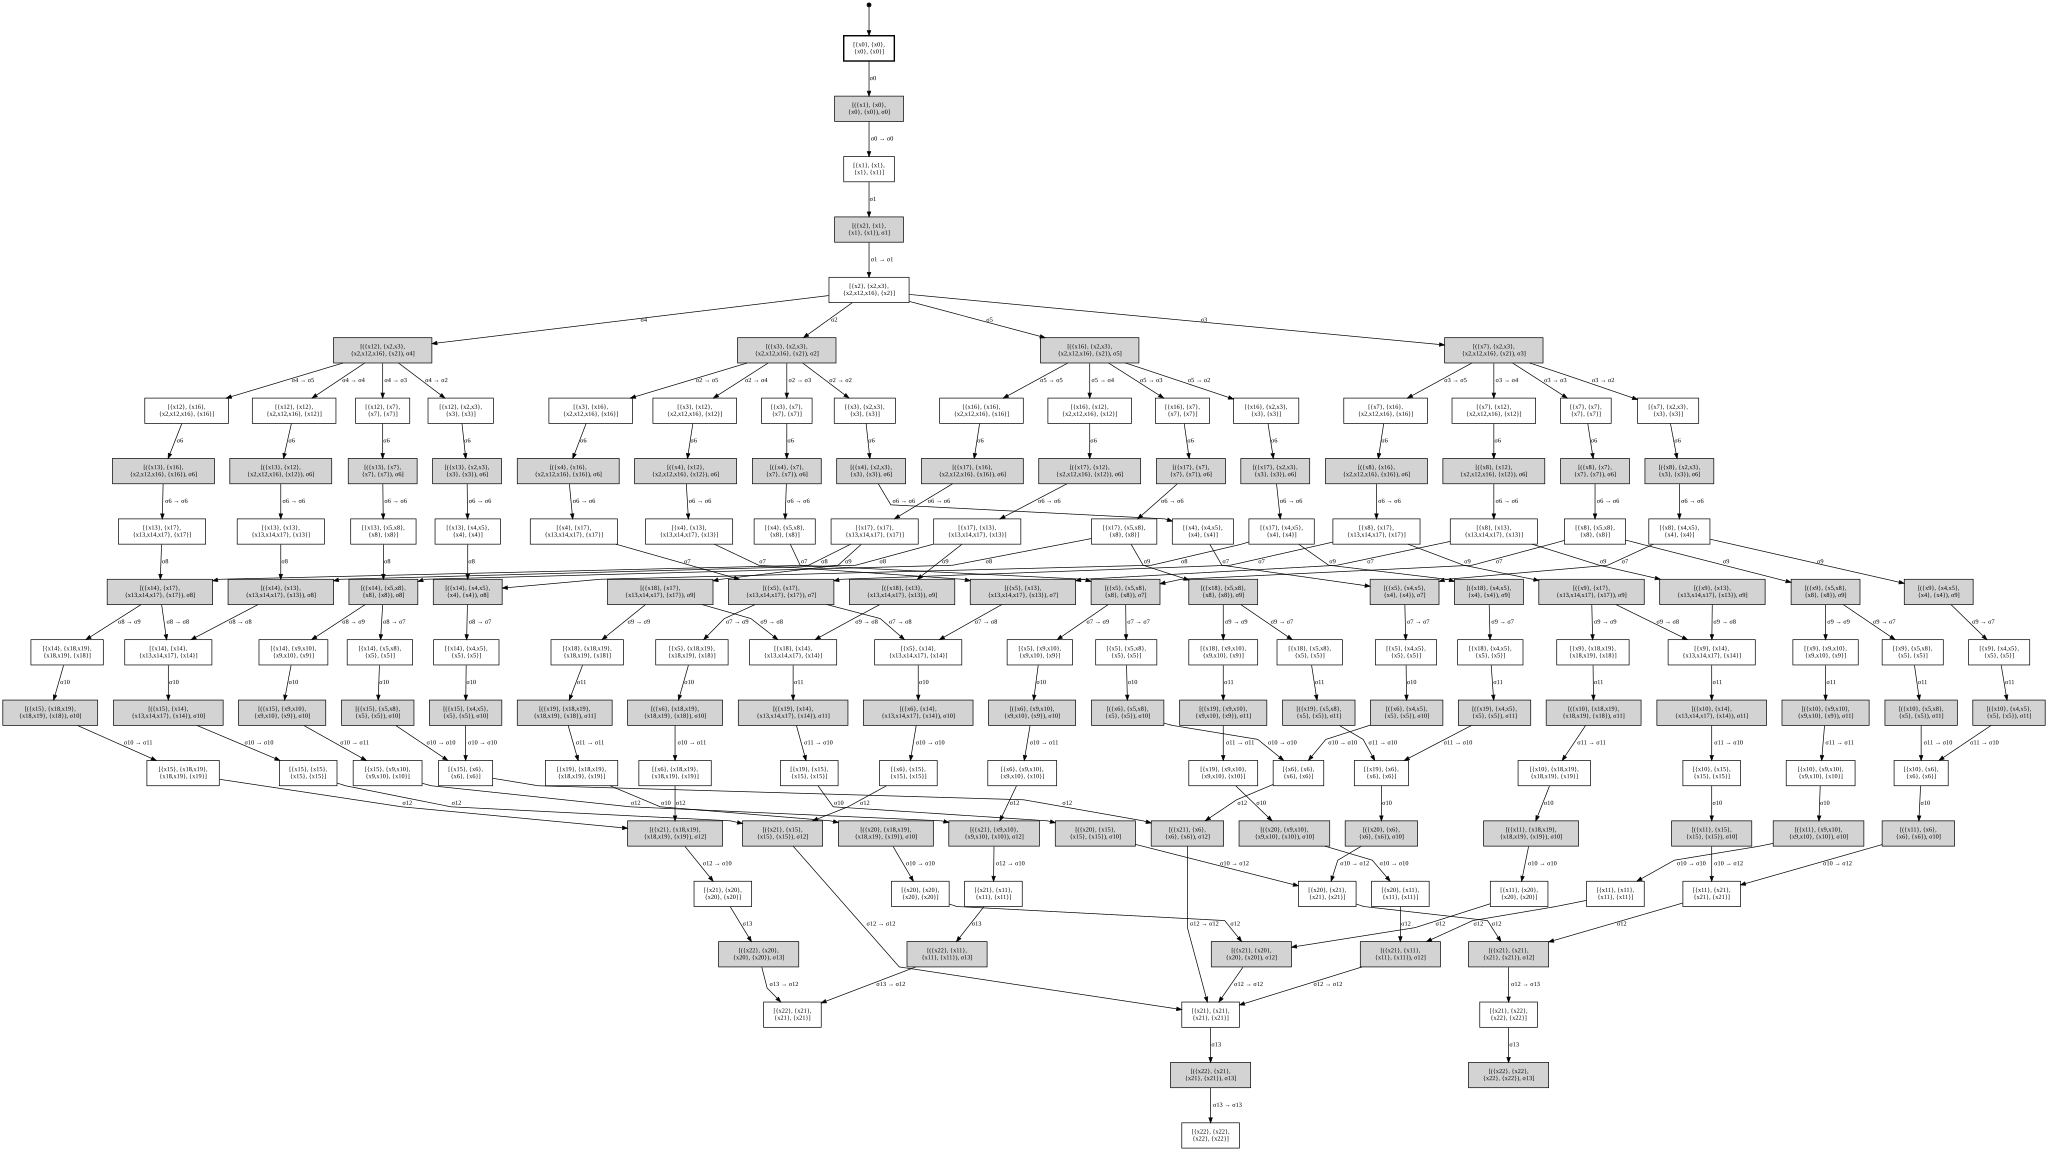

In [13]:
# ============================================================
# VISUALIZE THE MUTUAL EDIT GAME STRUCTURE M
# ============================================================

from graphviz import Digraph
from IPython.display import SVG, display


# ============================================================
# 1. PRETTY PRINTING
# ============================================================

def state_num(x):
    return int(x.split('_')[1])


def event_num(e):
    return int(e.split('_')[1])


def pretty_event(e):
    """
    sigma_3 -> σ3
    sigma_10 -> σ10
    """
    return "σ" + str(event_num(e))


def pretty_estimate(q):
    """
    frozenset({'x_3','x_7'})
        ->
    {x3,x7}
    """

    ordered = sorted(
        q,
        key=state_num
    )

    return "{" + ",".join(
        "x" + str(state_num(x))
        for x in ordered
    ) + "}"


# ============================================================
# 2. LABEL FOR XA STATE
# ============================================================
#
# XA = (q, q1, q2, qD)
# ============================================================

def XA_label(xA):

    q, q1, q2, qD = xA

    return (
        "["
        + pretty_estimate(q)
        + ", "
        + pretty_estimate(q1)
        + ",\n "
        + pretty_estimate(q2)
        + ", "
        + pretty_estimate(qD)
        + "]"
    )


# ============================================================
# 3. LABEL FOR XB STATE
# ============================================================
#
# XB = ((q,q1,q2,qD), sigma)
#
# Internally our code stores:
# (q,q1,q2,qD,sigma)
# ============================================================

def XB_label(xB):

    q, q1, q2, qD, sigma = xB

    return (
        "[("
        + pretty_estimate(q)
        + ", "
        + pretty_estimate(q1)
        + ",\n "
        + pretty_estimate(q2)
        + ", "
        + pretty_estimate(qD)
        + "), "
        + pretty_event(sigma)
        + "]"
    )


# ============================================================
# 4. GIVE EVERY GAME STATE A UNIQUE GRAPHVIZ NAME
# ============================================================

XA_list = list(M['XA_states'])
XB_list = list(M['XB_states'])

XA_name = {
    xA: f"XA_{i}"
    for i, xA in enumerate(XA_list)
}

XB_name = {
    xB: f"XB_{i}"
    for i, xB in enumerate(XB_list)
}


# ============================================================
# 5. CREATE GRAPH
# ============================================================

dot = Digraph(
    name="Mutual_Edit_Game",
    format="svg"
)

dot.attr(
    rankdir="TB",          # top -> bottom like your example
    splines="polyline",
    nodesep="0.30",
    ranksep="0.55",
    bgcolor="white"
)

dot.attr(
    "node",
    shape="box",
    fontname="Times New Roman",
    fontsize="9",
    margin="0.06,0.04"
)

dot.attr(
    "edge",
    fontname="Times New Roman",
    fontsize="9",
    arrowsize="0.7",
    penwidth="1.0"
)


# ============================================================
# 6. DRAW XA STATES
# ============================================================

for xA in XA_list:

    # Initial XA state slightly emphasized
    if xA == M['initial_state']:

        dot.node(
            XA_name[xA],
            label=XA_label(xA),
            shape="box",
            style="filled",
            fillcolor="white",
            penwidth="2.0"
        )

    else:

        dot.node(
            XA_name[xA],
            label=XA_label(xA),
            shape="box",
            style="filled",
            fillcolor="white"
        )


# ============================================================
# 7. DRAW XB STATES
# ============================================================

for xB in XB_list:

    dot.node(
        XB_name[xB],
        label=XB_label(xB),
        shape="box",
        style="filled",
        fillcolor="lightgray"
    )


# ============================================================
# 8. INITIAL ARROW
# ============================================================

dot.node(
    "START",
    label="",
    shape="point",
    width="0.08"
)

dot.edge(
    "START",
    XA_name[M['initial_state']]
)


# ============================================================
# 9. DRAW delta_SD
#
# XA --sigma--> XB
# ============================================================

for (xA, sigma), xB in M['delta_SD'].items():

    dot.edge(
        XA_name[xA],
        XB_name[xB],
        label=pretty_event(sigma)
    )


# ============================================================
# 10. DRAW delta_DS
#
# XB -- sigma -> omega --> XA
#
# sigma = original event
# omega = defender output
# ============================================================

for (xB, omega), xA_next in M['delta_DS'].items():

    sigma = xB[4]

    # no edit
    if omega == sigma:

        edit_label = (
            pretty_event(sigma)
            + " → "
            + pretty_event(omega)
        )

    # replacement
    else:

        edit_label = (
            pretty_event(sigma)
            + " → "
            + pretty_event(omega)
        )

    dot.edge(
        XB_name[xB],
        XA_name[xA_next],
        label=edit_label
    )


# ============================================================
# 11. SAVE AS SVG
# ============================================================

svg_file = dot.render(
    "mutual_edit_game",
    cleanup=True
)


# ============================================================
# 12. ALSO SAVE A PDF FOR YOUR PAPER
# ============================================================

dot_pdf = Digraph(
    name="Mutual_Edit_Game_PDF",
    format="pdf"
)

dot_pdf.body = dot.body

dot_pdf.render(
    "mutual_edit_game",
    cleanup=True
)


# ============================================================
# 13. DISPLAY
# ============================================================

display(
    SVG(
        filename="mutual_edit_game.svg"
    )
)

In [5]:
# ============================================================
# PRUNED MUTUAL EDIT GAME STRUCTURE PM
# TWO-AGENT CASE
#
# Run this AFTER the cell that constructs:
#
#   M['XA_states']
#   M['XB_states']
#   M['delta_SD']
#   M['delta_DS']
#   M['initial_state']
#
# Also assumes:
#   S1, S2
#
# ============================================================


# ============================================================
# 1. ORIGINAL GAME COMPONENTS
# ============================================================

XA = set(M['XA_states'])
XB = set(M['XB_states'])

delta_SD = M['delta_SD']
delta_DS = M['delta_DS']

chi_0 = M['initial_state']


# ============================================================
# 2. CONFIDENTIALITY UTILITY FOR XA STATES
# ============================================================
#
# U(chi_A) = 0 if:
#
#   (q subseteq S2 AND q1 subseteq S2)
#
# OR
#
#   (q subseteq S1 AND q2 subseteq S1)
#
# This follows your complete-disclosure definition exactly.
# ============================================================

def confidentiality_violation(xA):

    q, q1, q2, qD = xA

    # Agent A1 completely identifies secret S2
    violation_A1 = (
        q.issubset(S2)
        and
        q1.issubset(S2)
    )

    # Agent A2 completely identifies secret S1
    violation_A2 = (
        q.issubset(S1)
        and
        q2.issubset(S1)
    )

    return violation_A1 or violation_A2


# ============================================================
# 3. INITIAL CONTROL POLICY C
# ============================================================
#
# C(chi_B) = all currently admissible edit outputs
#            at chi_B
#
# Since the original game M was already constructed,
# delta_DS contains exactly the defined replacement outputs.
# ============================================================

C_original = {
    xB: set()
    for xB in XB
}

for (xB, omega), xA_next in delta_DS.items():

    if xB in C_original:

        C_original[xB].add(
            omega
        )


# ============================================================
# 4. AVAILABILITY UTILITY FOR XB STATES
# ============================================================
#
# U(chi_B) = 0 if:
#
# for every admissible omega,
# delta_DS(chi_B, omega) is undefined.
#
# In our constructed game, undefined delta_DS transitions
# are not stored.
#
# Therefore:
#
# availability violation <=> no outgoing edit output exists.
# ============================================================

def availability_violation(xB):

    return len(
        C_original.get(xB, set())
    ) == 0


# ============================================================
# 5. INITIAL PROBLEMATIC SETS
# ============================================================

P_A = {
    xA
    for xA in XA
    if confidentiality_violation(xA)
}


P_B = {
    xB
    for xB in XB
    if availability_violation(xB)
}


# Store the DIRECT utility-zero states separately.
# This will be useful later for the reviewer statistics.

P_A_initial = set(P_A)
P_B_initial = set(P_B)


# ============================================================
# 6. HELPER:
# OUTGOING SYSTEM TRANSITIONS FROM XA
# ============================================================

SD_outgoing = {
    xA: []
    for xA in XA
}

for (xA, sigma), xB in delta_SD.items():

    SD_outgoing.setdefault(
        xA,
        []
    ).append(
        (sigma, xB)
    )


# ============================================================
# 7. HELPER:
# OUTGOING EDIT TRANSITIONS FROM XB
# ============================================================

DS_outgoing = {
    xB: {}
    for xB in XB
}

for (xB, omega), xA_next in delta_DS.items():

    DS_outgoing.setdefault(
        xB,
        {}
    )[omega] = xA_next


# ============================================================
# 8. FIXED-POINT PRUNING
# ============================================================
#
# Repeat:
#
# 1. XA becomes problematic if THERE EXISTS an
#    uncontrollable system event leading into P_B.
#
# 2. XB becomes problematic if ALL edit outputs are
#    undefined or lead into P_A.
#
# until no new states are added.
# ============================================================

pruning_history = []

iteration = 0


while True:

    iteration += 1

    old_P_A = set(P_A)
    old_P_B = set(P_B)


    # ========================================================
    # STEP A:
    # Mark XA states that necessarily may lead to
    # problematic XB states through system-generated events.
    # ========================================================

    new_PA = set()

    for xA in XA - P_A:

        for sigma, xB_next in SD_outgoing.get(
            xA,
            []
        ):

            if xB_next in P_B:

                new_PA.add(
                    xA
                )

                break


    P_A.update(
        new_PA
    )


    # ========================================================
    # STEP B:
    # Mark XB states having no safe edit output.
    # ========================================================

    new_PB = set()

    for xB in XB - P_B:

        outputs = C_original.get(
            xB,
            set()
        )


        # If no outputs exist, availability is violated.
        if len(outputs) == 0:

            new_PB.add(
                xB
            )

            continue


        # Check whether ALL outputs are unsafe.
        all_outputs_bad = True


        for omega in outputs:

            xA_next = delta_DS.get(
                (xB, omega)
            )


            # A safe output exists if:
            #
            # delta_DS is defined
            # AND target is not problematic.
            if (
                xA_next is not None
                and
                xA_next not in P_A
            ):

                all_outputs_bad = False

                break


        if all_outputs_bad:

            new_PB.add(
                xB
            )


    P_B.update(
        new_PB
    )


    # ========================================================
    # SAVE ITERATION INFORMATION
    # ========================================================

    pruning_history.append({

        'iteration':
            iteration,

        'new_PA':
            set(new_PA),

        'new_PB':
            set(new_PB),

        'total_PA':
            len(P_A),

        'total_PB':
            len(P_B)
    })


    # ========================================================
    # FIXED POINT TEST
    # ========================================================

    if (
        P_A == old_P_A
        and
        P_B == old_P_B
    ):

        break


# ============================================================
# 9. CHECK INITIAL STATE
# ============================================================

if chi_0 in P_A:

    PM = {

        'empty':
            True,

        'initial_state':
            chi_0,

        'XA_states':
            set(),

        'XB_states':
            set(),

        'X_P':
            set(),

        'delta_SD':
            {},

        'delta_DS':
            {},

        'policy':
            {},

        'P_A':
            P_A,

        'P_B':
            P_B,

        'P_A_initial':
            P_A_initial,

        'P_B_initial':
            P_B_initial,

        'pruning_history':
            pruning_history
    }


    print(
        "PM is EMPTY."
    )

    print(
        "The initial state chi_0 became problematic."
    )

    print(
        "No valid replacement policy exists "
        "under the current configuration."
    )


# ============================================================
# 10. OTHERWISE CONTINUE SYNTHESIS
# ============================================================

else:

    # ========================================================
    # COPY ORIGINAL POLICY
    # ========================================================

    C_final = {

        xB:
            set(outputs)

        for xB, outputs
        in C_original.items()

        if xB not in P_B
    }


    # ========================================================
    # 11. DISABLE EDIT OUTPUTS LEADING TO P_A
    # ========================================================

    disabled_edit_operations = set()


    for xB in list(
        C_final.keys()
    ):

        for omega in list(
            C_final[xB]
        ):

            xA_next = delta_DS.get(
                (xB, omega)
            )


            # Disable if transition is undefined
            # or target belongs to P_A
            if (
                xA_next is None
                or
                xA_next in P_A
            ):

                C_final[xB].remove(
                    omega
                )

                disabled_edit_operations.add(
                    (xB, omega)
                )


    # ========================================================
    # 12. COMPUTE REACHABLE PRUNED PORTION
    # ========================================================
    #
    # Start from chi_0.
    #
    # Alternate:
    #
    # XA --sigma--> XB
    #
    # XB --omega--> XA
    #
    # Problematic states and disabled edits are excluded.
    # ========================================================

    reachable_XA = set()
    reachable_XB = set()

    pruned_delta_SD = {}
    pruned_delta_DS = {}


    # Queue entries:
    #
    # ('A', XA_state)
    # ('B', XB_state)

    queue = [
        ('A', chi_0)
    ]


    while queue:

        state_type, state = queue.pop(0)


        # ====================================================
        # XA STATE
        # ====================================================

        if state_type == 'A':

            xA = state


            if xA in reachable_XA:
                continue


            if xA in P_A:
                continue


            reachable_XA.add(
                xA
            )


            # Follow surviving uncontrollable
            # system transitions.
            for sigma, xB_next in SD_outgoing.get(
                xA,
                []
            ):

                # Problematic XB removed
                if xB_next in P_B:
                    continue


                pruned_delta_SD[
                    (xA, sigma)
                ] = xB_next


                if xB_next not in reachable_XB:

                    queue.append(
                        ('B', xB_next)
                    )


        # ====================================================
        # XB STATE
        # ====================================================

        else:

            xB = state


            if xB in reachable_XB:
                continue


            if xB in P_B:
                continue


            reachable_XB.add(
                xB
            )


            # Follow only the edit outputs
            # remaining in C_final.
            for omega in C_final.get(
                xB,
                set()
            ):

                xA_next = delta_DS.get(
                    (xB, omega)
                )


                if xA_next is None:
                    continue


                if xA_next in P_A:
                    continue


                pruned_delta_DS[
                    (xB, omega)
                ] = xA_next


                if xA_next not in reachable_XA:

                    queue.append(
                        ('A', xA_next)
                    )


    # ========================================================
    # 13. REMOVE POLICY ENTRIES FOR UNREACHABLE XB STATES
    # ========================================================

    executable_policy = {}


    for xB in reachable_XB:

        enabled_outputs = set()


        for omega in C_final.get(
            xB,
            set()
        ):

            if (
                (xB, omega)
                in pruned_delta_DS
            ):

                enabled_outputs.add(
                    omega
                )


        executable_policy[
            xB
        ] = enabled_outputs


    # ========================================================
    # 14. FINAL PRUNED STATE SET XP
    # ========================================================

    X_P = (
        reachable_XA
        |
        reachable_XB
    )


    # ========================================================
    # 15. BUILD PM
    # ========================================================

    PM = {

        'empty':
            False,

        'initial_state':
            chi_0,

        # Reachable surviving states
        'XA_states':
            reachable_XA,

        'XB_states':
            reachable_XB,

        'X_P':
            X_P,

        # Pruned transition function Delta
        'delta_SD':
            pruned_delta_SD,

        'delta_DS':
            pruned_delta_DS,

        # Final executable policy C
        'policy':
            executable_policy,

        # Problematic states after fixed point
        'P_A':
            P_A,

        'P_B':
            P_B,

        # Direct utility-zero states
        'P_A_initial':
            P_A_initial,

        'P_B_initial':
            P_B_initial,

        # Explicitly disabled edit actions
        'disabled_edit_operations':
            disabled_edit_operations,

        # Fixed-point information
        'pruning_history':
            pruning_history,

        'iterations':
            iteration,


        'edit_type':
            'replacement'
    }


    # ========================================================
    # 16. BASIC CONFIRMATION
    # ========================================================

    print(
        "Pruned mutual edit game PM "
        "constructed successfully."
    )

    print(
        "Initial state remains safe."
    )

    print(
        "Fixed-point iterations:",
        iteration
    )

Pruned mutual edit game PM constructed successfully.
Initial state remains safe.
Fixed-point iterations: 7


In [14]:
# ============================================================
# SHOW FIXED-POINT PRUNING HISTORY
# ============================================================

print("PRUNING HISTORY")
print("=" * 70)

for h in PM['pruning_history']:

    print(
        f"Iteration {h['iteration']}: "
        f"new P_A = {len(h['new_PA'])}, "
        f"new P_B = {len(h['new_PB'])}, "
        f"total P_A = {h['total_PA']}, "
        f"total P_B = {h['total_PB']}"
    )

PRUNING HISTORY
Iteration 1: new P_A = 1, new P_B = 3, total P_A = 5, total P_B = 4
Iteration 2: new P_A = 2, new P_B = 4, total P_A = 7, total P_B = 8
Iteration 3: new P_A = 4, new P_B = 6, total P_A = 11, total P_B = 14
Iteration 4: new P_A = 6, new P_B = 6, total P_A = 17, total P_B = 20
Iteration 5: new P_A = 6, new P_B = 6, total P_A = 23, total P_B = 26
Iteration 6: new P_A = 6, new P_B = 0, total P_A = 29, total P_B = 26
Iteration 7: new P_A = 0, new P_B = 0, total P_A = 29, total P_B = 26


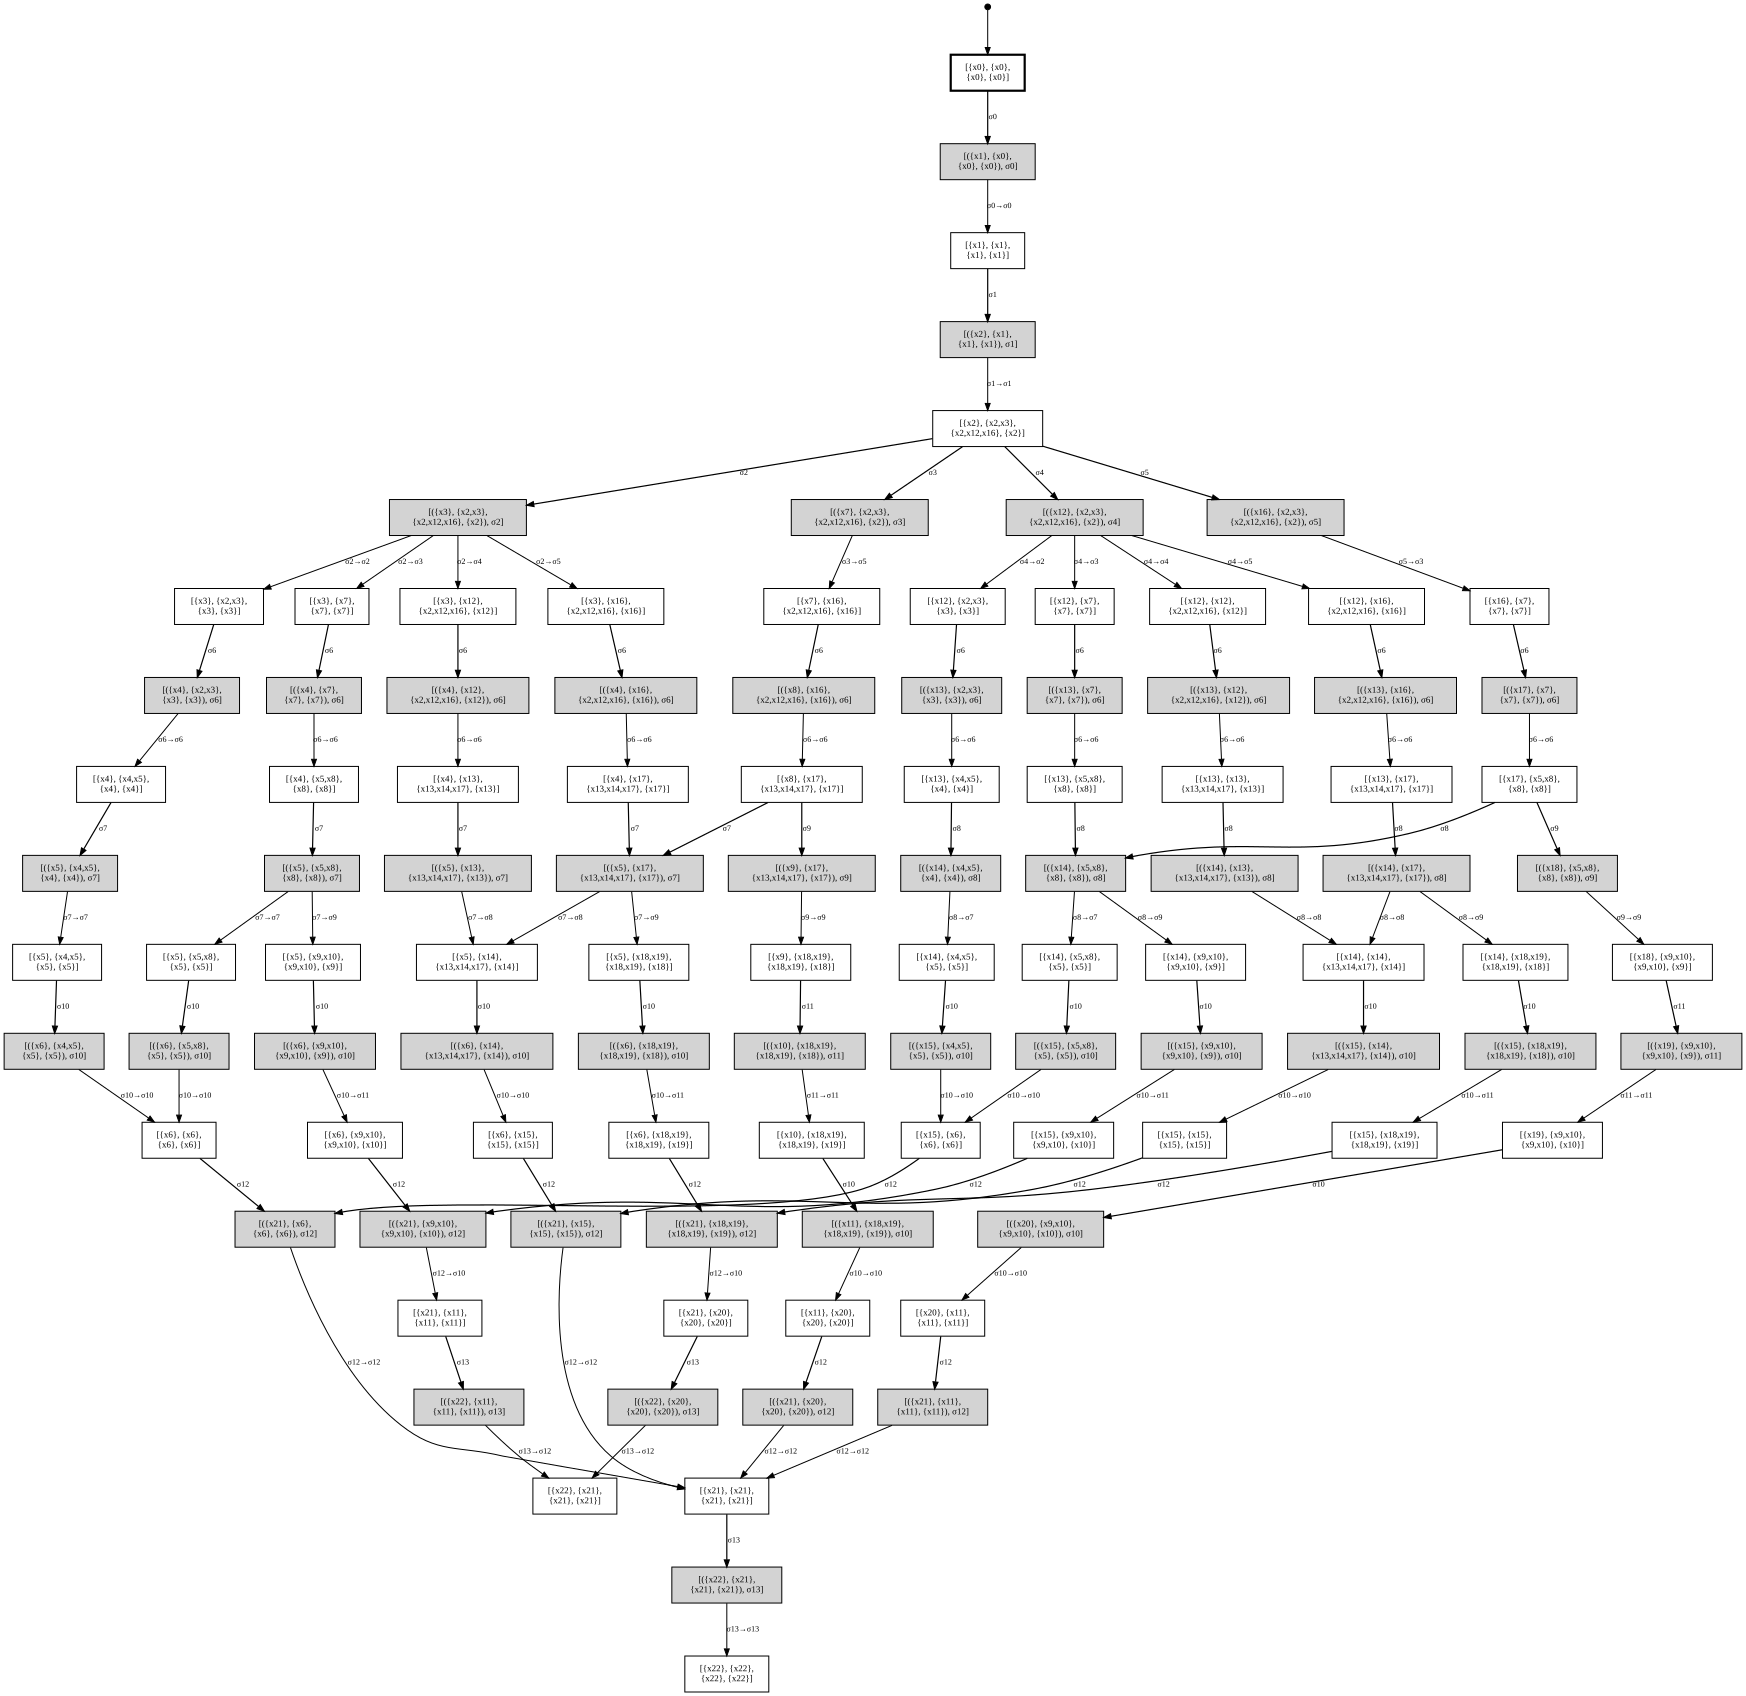

In [15]:
# ============================================================
# VISUALIZE PRUNED MUTUAL EDIT GAME PM
# ALL ARROWS SOLID
# ============================================================

from graphviz import Digraph
from IPython.display import SVG, display


# ============================================================
# 1. CHECK THAT PM IS NOT EMPTY
# ============================================================

if PM.get('empty', False):
    raise ValueError(
        "PM is empty. No valid executable policy exists."
    )


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_state_number(state):
    return int(state.split('_')[1])


def get_event_number(event):
    return int(event.split('_')[1])


def pretty_event(event):
    """
    sigma_0  -> σ0
    sigma_10 -> σ10
    """
    return "σ" + str(get_event_number(event))


def pretty_estimate(q):
    """
    frozenset({'x_3','x_7'})
        ->
    {x3,x7}
    """

    ordered = sorted(
        q,
        key=get_state_number
    )

    return "{" + ",".join(
        "x" + str(get_state_number(x))
        for x in ordered
    ) + "}"


# ============================================================
# 3. XA LABEL
#
# XA = (q, q1, q2, qD)
# ============================================================

def PM_XA_label(xA):

    q, q1, q2, qD = xA

    return (
        "["
        + pretty_estimate(q)
        + ", "
        + pretty_estimate(q1)
        + ",\n"
        + pretty_estimate(q2)
        + ", "
        + pretty_estimate(qD)
        + "]"
    )


# ============================================================
# 4. XB LABEL
#
# XB = (q, q1, q2, qD, sigma)
# ============================================================

def PM_XB_label(xB):

    q, q1, q2, qD, sigma = xB

    return (
        "[("
        + pretty_estimate(q)
        + ", "
        + pretty_estimate(q1)
        + ",\n"
        + pretty_estimate(q2)
        + ", "
        + pretty_estimate(qD)
        + "), "
        + pretty_event(sigma)
        + "]"
    )


# ============================================================
# 5. GET FINAL REACHABLE PM STATES
# ============================================================

XA_PM = set(PM['XA_states'])
XB_PM = set(PM['XB_states'])

delta_SD_PM = PM['delta_SD']
delta_DS_PM = PM['delta_DS']

chi_0_PM = PM['initial_state']


# ============================================================
# 6. STABLE SORTING OF XA STATES
# ============================================================

def XA_sort_key(xA):

    q, q1, q2, qD = xA

    return (
        tuple(sorted(get_state_number(x) for x in q)),
        tuple(sorted(get_state_number(x) for x in q1)),
        tuple(sorted(get_state_number(x) for x in q2)),
        tuple(sorted(get_state_number(x) for x in qD))
    )


# ============================================================
# 7. STABLE SORTING OF XB STATES
# ============================================================

def XB_sort_key(xB):

    q, q1, q2, qD, sigma = xB

    return (
        tuple(sorted(get_state_number(x) for x in q)),
        tuple(sorted(get_state_number(x) for x in q1)),
        tuple(sorted(get_state_number(x) for x in q2)),
        tuple(sorted(get_state_number(x) for x in qD)),
        get_event_number(sigma)
    )


XA_list = sorted(
    XA_PM,
    key=XA_sort_key
)

XB_list = sorted(
    XB_PM,
    key=XB_sort_key
)


# ============================================================
# 8. UNIQUE GRAPHVIZ NODE NAMES
# ============================================================

XA_name = {
    xA: f"PA_{i}"
    for i, xA in enumerate(XA_list)
}

XB_name = {
    xB: f"PB_{i}"
    for i, xB in enumerate(XB_list)
}


# ============================================================
# 9. CREATE GRAPH
# ============================================================

dot = Digraph(
    name="Pruned_Mutual_Edit_Game",
    format="svg"
)

dot.attr(
    rankdir="TB",
    splines="spline",
    nodesep="0.35",
    ranksep="0.60",
    bgcolor="white",
    concentrate="false"
)

dot.attr(
    "node",
    shape="box",
    fontname="Times New Roman",
    fontsize="9",
    margin="0.07,0.05"
)

# ALL EDGES SOLID
dot.attr(
    "edge",
    fontname="Times New Roman",
    fontsize="8",
    arrowsize="0.70",
    penwidth="1.0",
    style="solid",
    arrowhead="normal"
)


# ============================================================
# 10. DRAW XA STATES
#
# XA = white
# ============================================================

for xA in XA_list:

    if xA == chi_0_PM:

        dot.node(
            XA_name[xA],
            label=PM_XA_label(xA),
            style="filled",
            fillcolor="white",
            penwidth="2.2"
        )

    else:

        dot.node(
            XA_name[xA],
            label=PM_XA_label(xA),
            style="filled",
            fillcolor="white",
            penwidth="1.0"
        )


# ============================================================
# 11. DRAW XB STATES
#
# XB = light gray
# ============================================================

for xB in XB_list:

    dot.node(
        XB_name[xB],
        label=PM_XB_label(xB),
        style="filled",
        fillcolor="lightgray",
        penwidth="1.0"
    )


# ============================================================
# 12. INITIAL ARROW
# ============================================================

dot.node(
    "PM_START",
    label="",
    shape="point",
    width="0.08"
)

dot.edge(
    "PM_START",
    XA_name[chi_0_PM],
    style="solid"
)


# ============================================================
# 13. GROUP delta_SD EDGES
#
# XA --sigma--> XB
# ============================================================

grouped_SD = {}

for (xA, sigma), xB in delta_SD_PM.items():

    key = (
        xA,
        xB
    )

    grouped_SD.setdefault(
        key,
        []
    ).append(
        sigma
    )


for (xA, xB), events in grouped_SD.items():

    events = sorted(
        events,
        key=get_event_number
    )

    label = ", ".join(
        pretty_event(e)
        for e in events
    )

    dot.edge(
        XA_name[xA],
        XB_name[xB],
        label=label,
        style="solid",
        penwidth="1.2",
        arrowhead="normal"
    )


# ============================================================
# 14. GROUP delta_DS EDGES
#
# XB -- sigma -> omega --> XA
#
# These are the edit-function decisions that survived pruning.
# ============================================================

grouped_DS = {}

for (xB, omega), xA_next in delta_DS_PM.items():

    key = (
        xB,
        xA_next
    )

    grouped_DS.setdefault(
        key,
        []
    ).append(
        omega
    )


for (xB, xA_next), outputs in grouped_DS.items():

    sigma = xB[4]

    outputs = sorted(
        outputs,
        key=get_event_number
    )

    labels = []

    for omega in outputs:

        labels.append(
            pretty_event(sigma)
            + "→"
            + pretty_event(omega)
        )


    label = "\n".join(
        labels
    )

    dot.edge(
        XB_name[xB],
        XA_name[xA_next],
        label=label,
        style="solid",
        penwidth="1.0",
        arrowhead="normal"
    )


# ============================================================
# 15. SAVE SVG
# ============================================================

dot.render(
    "pruned_mutual_edit_game_PM",
    format="svg",
    cleanup=True
)


# ============================================================
# 16. SAVE PDF
# ============================================================

dot.render(
    "pruned_mutual_edit_game_PM",
    format="pdf",
    cleanup=True
)


# ============================================================
# 17. DISPLAY
# ============================================================

display(
    SVG(
        filename="pruned_mutual_edit_game_PM.svg"
    )
)

In [16]:
# ============================================================
# REVIEWER 2 — QUANTITATIVE SUMMARY
# ORIGINAL GAME, PRUNING, AND FINAL POLICY
# ============================================================

# ------------------------------------------------------------
# 1. ORIGINAL MUTUAL EDIT GAME M
# ------------------------------------------------------------

original_XA = len(M['XA_states'])
original_XB = len(M['XB_states'])
original_total_states = original_XA + original_XB

original_delta_SD = len(M['delta_SD'])
original_delta_DS = len(M['delta_DS'])


# ------------------------------------------------------------
# 2. DIRECT UTILITY-ZERO STATES
# ------------------------------------------------------------

direct_confidentiality_states = len(PM['P_A_initial'])
direct_availability_states = len(PM['P_B_initial'])

direct_problematic_total = (
    direct_confidentiality_states
    + direct_availability_states
)


# ------------------------------------------------------------
# 3. FINAL PROBLEMATIC SETS AFTER FIXED-POINT PRUNING
# ------------------------------------------------------------

final_PA = len(PM['P_A'])
final_PB = len(PM['P_B'])

final_problematic_total = final_PA + final_PB

additional_PA = (
    final_PA
    - direct_confidentiality_states
)

additional_PB = (
    final_PB
    - direct_availability_states
)

additional_problematic_total = (
    additional_PA
    + additional_PB
)


# ------------------------------------------------------------
# 4. FINAL REACHABLE PRUNED GAME PM
# ------------------------------------------------------------

final_XA = len(PM['XA_states'])
final_XB = len(PM['XB_states'])
final_total_states = len(PM['X_P'])

final_delta_SD = len(PM['delta_SD'])
final_delta_DS = len(PM['delta_DS'])


# ------------------------------------------------------------
# 5. STATES REMOVED FROM FINAL EXECUTABLE GAME
# ------------------------------------------------------------

states_absent_from_PM = (
    original_total_states
    - final_total_states
)

# Safe states that were not classified problematic
# but became unreachable after pruning
safe_original_XA = set(M['XA_states']) - set(PM['P_A'])
safe_original_XB = set(M['XB_states']) - set(PM['P_B'])

safe_but_unreachable_XA = (
    safe_original_XA
    - set(PM['XA_states'])
)

safe_but_unreachable_XB = (
    safe_original_XB
    - set(PM['XB_states'])
)

safe_but_unreachable_total = (
    len(safe_but_unreachable_XA)
    + len(safe_but_unreachable_XB)
)


# ------------------------------------------------------------
# 6. EDIT OPERATIONS
# ------------------------------------------------------------

explicitly_disabled_edits = len(
    PM['disabled_edit_operations']
)

total_edit_transitions_removed = (
    original_delta_DS
    - final_delta_DS
)

# These disappear because their states are pruned/unreachable,
# rather than because the individual edit was explicitly disabled.
other_removed_edit_transitions = (
    total_edit_transitions_removed
    - explicitly_disabled_edits
)


# ------------------------------------------------------------
# 7. FINAL EXECUTABLE POLICY
# ------------------------------------------------------------

policy_states = len(PM['policy'])

enabled_policy_actions = sum(
    len(outputs)
    for outputs in PM['policy'].values()
)


# ------------------------------------------------------------
# 8. FIXED-POINT INFORMATION
# ------------------------------------------------------------

fixed_point_iterations = PM['iterations']


# ------------------------------------------------------------
# 9. PRINT FINAL SUMMARY
# ------------------------------------------------------------

print("=" * 72)
print("LARGE CLOUD EXAMPLE — COMPUTATIONAL RESULTS")
print("=" * 72)

print("\n1. ORIGINAL MUTUAL EDIT GAME M")
print("-" * 72)
print(f"XA states                              : {original_XA}")
print(f"XB states                              : {original_XB}")
print(f"Total states in M                      : {original_total_states}")
print(f"delta_SD transitions                   : {original_delta_SD}")
print(f"delta_DS edit transitions              : {original_delta_DS}")

print("\n2. DIRECT UTILITY-ZERO STATES")
print("-" * 72)
print(f"Confidentiality-violating XA states    : {direct_confidentiality_states}")
print(f"Availability-violating XB states       : {direct_availability_states}")
print(f"Total direct problematic states        : {direct_problematic_total}")

print("\n3. FIXED-POINT PRUNING")
print("-" * 72)
print(f"Final P_A                              : {final_PA}")
print(f"Final P_B                              : {final_PB}")
print(f"Total problematic states               : {final_problematic_total}")
print(f"Additional P_A by propagation          : {additional_PA}")
print(f"Additional P_B by propagation          : {additional_PB}")
print(f"Additional problematic states          : {additional_problematic_total}")
print(f"Fixed-point iterations                 : {fixed_point_iterations}")

print("\n4. FINAL PRUNED GAME PM")
print("-" * 72)
print(f"Reachable XA states                    : {final_XA}")
print(f"Reachable XB states                    : {final_XB}")
print(f"Total reachable states in PM           : {final_total_states}")
print(f"PM delta_SD transitions                : {final_delta_SD}")
print(f"PM delta_DS transitions                : {final_delta_DS}")

print("\n5. STATE REMOVAL")
print("-" * 72)
print(f"States absent from final PM            : {states_absent_from_PM}")
print(f"Problematic states removed             : {final_problematic_total}")
print(f"Safe but unreachable states            : {safe_but_unreachable_total}")

print("\n6. EDIT OPERATIONS")
print("-" * 72)
print(f"Original edit transitions              : {original_delta_DS}")
print(f"Explicitly disabled unsafe edits       : {explicitly_disabled_edits}")
print(f"Total edit transitions absent from PM  : {total_edit_transitions_removed}")
print(f"Removed with pruned/unreachable states : {other_removed_edit_transitions}")
print(f"Final executable edit transitions      : {final_delta_DS}")

print("\n7. FINAL EXECUTABLE POLICY")
print("-" * 72)
print(f"Reachable edit states with policy      : {policy_states}")
print(f"Total enabled policy actions           : {enabled_policy_actions}")

print("\n" + "=" * 72)

LARGE CLOUD EXAMPLE — COMPUTATIONAL RESULTS

1. ORIGINAL MUTUAL EDIT GAME M
------------------------------------------------------------------------
XA states                              : 83
XB states                              : 77
Total states in M                      : 160
delta_SD transitions                   : 92
delta_DS edit transitions              : 96

2. DIRECT UTILITY-ZERO STATES
------------------------------------------------------------------------
Confidentiality-violating XA states    : 4
Availability-violating XB states       : 1
Total direct problematic states        : 5

3. FIXED-POINT PRUNING
------------------------------------------------------------------------
Final P_A                              : 29
Final P_B                              : 26
Total problematic states               : 55
Additional P_A by propagation          : 25
Additional P_B by propagation          : 25
Additional problematic states          : 50
Fixed-point iterations              